#**Installing Dependencies**

In [ ]:
%pip install "tensorflow[and-cuda]" scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/22.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 833.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nccl-cu12
  

#**Loading and splitting our dataset**

In [51]:
import tensorflow as tf

# Load the mnist dataset
mnist = tf.keras.datasets.mnist

# Splitting the data into training data and validation data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the image data so as the tensors contain only 0s and 1s (white and black)
X_train, X_test = X_train / 255.0, X_test / 255.0

# **Creating our model architecture layer by layer**

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout

model = Sequential()
# Shape of X_train
model.add(Input((28,28)))
# Flatten tenser from 28 x 28 to 784 - so our input layer will have 784 neurons
model.add(Flatten())
# Number of neurons in a layer. More => Longer training time + possible overfitting, but more parameters can be tweaked (better for more complex problems). We also used an ACTIVATION FUNCTION
model.add(Dense(128, activation='relu'))
# 20% chance a connection will not be there when we do an iteration
model.add(Dropout(0.2))
# Output layer - 10 because we are predicting digits 0-9, so we need a neuron for each (10 neurons total)
model.add(Dense(10))

We now have a totally dumb model, but a model with set hyperparameters indeed. Below is an example of our model outputting nonsense for an input :)

In [25]:
nonsense_pred = model(X_train[:1]).numpy()

nonsense_pred

array([[ 0.4670021 , -0.29298675, -0.16148947, -0.37723672,  0.00246408,
         0.16716842,  0.21656446, -0.44045052, -0.20974778, -0.11664374]],
      dtype=float32)

In the above, we get a numpy array of shape (1,10). This is because our output layer has 10 neurons for the digits 0-9. Each value in the tensor represent the logit(initial gut feeling) for the corresponding output layer neuron. We must pass these logits through a softmax function to get the probability of each output layer neuron as a number between 0 and 1.

Let us apply the softmax function to our logits predicted to get the probability of each output layer neuron, as shown below.

In [26]:
tf.nn.softmax(nonsense_pred).numpy()

array([[0.16533144, 0.07732082, 0.08818709, 0.07107341, 0.10389847,
        0.12250093, 0.12870392, 0.06671965, 0.08403239, 0.09223191]],
      dtype=float32)

As we can see, the values in the tensor are now probabilities that add up to 1. But again, our output is nonsense right now, because our model is untrained. To show this, let us compute the loss for this prediction, as showbn below.

In [27]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

loss_fn = SparseCategoricalCrossentropy(from_logits=True)

If the logits were totally random, then by definition of random variables, the probability of each logit should be (1/number of neurons in output layer) = (1/10). The corresponsing loss for a random prediction should be: -tf.math.log(1/10) = 2.3025851249694824. We are using log because we are using the SparseCategoricalCrossentropy loss function.

In [28]:
# Compute the loss between expected output and actual output
loss_fn(y_train[:1], nonsense_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=2.0996365547180176>

As we can see, the computed loss is very close to the random input loss, which shows our model is totally untrained (not a proof but an observation).

Now we start compiling the model and train it. To compile the model means to define an optimizer, to specify a loss function, to decide on the metrics and we make the model ready for training. Basically, we are specifying the training arguments.

In [29]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.01)

# The optimizer is what performs backprogation to tweak the model weights to improve the accuracy metric chosen below (as you can see, these are basically training arguments)
model.compile(optimizer=optimizer, loss =loss_fn, metrics=["accuracy"])

# Train model - the epoch is the number of times we train the model on the whole training data
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9055 - loss: 0.3151
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9325 - loss: 0.2408
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9381 - loss: 0.2245
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9433 - loss: 0.2148
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9445 - loss: 0.2057
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9472 - loss: 0.2051
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9494 - loss: 0.1957
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9511 - loss: 0.1933
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9522 - loss: 0.1859
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9531 - loss: 0.1856


Now that the model is trained, let us evaluate it on unseen but similar data.

In [30]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9622 - loss: 0.2165


[0.21648159623146057, 0.9621999859809875]

We can keep tuning the hyperparameters to try to achieve better accuracy but beware of overfitting. Moreover, high accuracy does not necessarily mean the model is performing well. We should also check the **f1-score**.

However, what we are doing is also not totally correct. Usually, we reserve the testing data for the very end, after hyperparameter tuning has been done. We must usually split our data into **training data**, **validation data** and **testing data**.

It is the validation data that must be used for hyperparameter tweaking.

Let us test our model with this example:

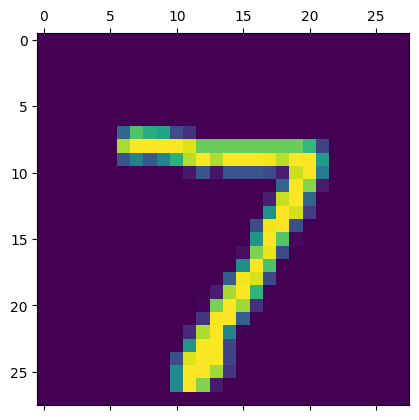

In [31]:
from matplotlib import pyplot as plt

plt.matshow(X_test[0])

In [32]:
import numpy as np

y_pred = model.predict(X_test)

y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([ -39.760834 ,  -27.224466 ,  -14.896857 ,   -0.7329618,
        -36.1145   ,  -19.499466 , -140.585    ,   40.06404  ,
        -32.065994 ,  -18.103807 ], dtype=float32)

In [39]:
np.argmax(y_pred[0])

np.int64(7)

Right now, our output is a tensor containing the probabilitity of each output neuron for each image input. To convert the output to the corresponding labels, we use:

In [43]:
y_pred_labels = [int(np.argmax(i)) for i in y_pred]
y_pred_labels[:5]

[7, 2, 1, 0, 4]

Let us compare it with our actual results:

In [42]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

As we can see, they match! 😉

Finally, let us look at the **confusion** matrix of our predictions:

In [44]:
confusion_matrix = tf.math.confusion_matrix(labels=y_test, predictions=y_pred_labels)

confusion_matrix

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 965,    0,    4,    0,    0,    0,    3,    2,    4,    2],
       [   0, 1119,    8,    0,    1,    0,    1,    1,    4,    1],
       [   6,    2, 1005,    7,    0,    0,    1,    5,    5,    1],
       [   1,    0,   16,  968,    1,    5,    0,    6,    3,   10],
       [   5,    2,    8,    0,  941,    1,    6,    1,    3,   15],
       [   3,    1,    0,   15,    1,  850,    7,    2,    8,    5],
       [   9,    3,    0,    1,    7,    9,  921,    0,    7,    1],
       [   1,    5,   18,    7,    3,    0,    0,  977,    4,   13],
       [   4,    4,    8,    4,    9,   16,    1,    3,  916,    9],
       [   2,    5,    1,    7,   19,    5,    0,    3,    7,  960]],
      dtype=int32)>

To better understand the confusion matrix, let us depict it graphically:

Text(95.72222222222221, 0.5, 'Truth')

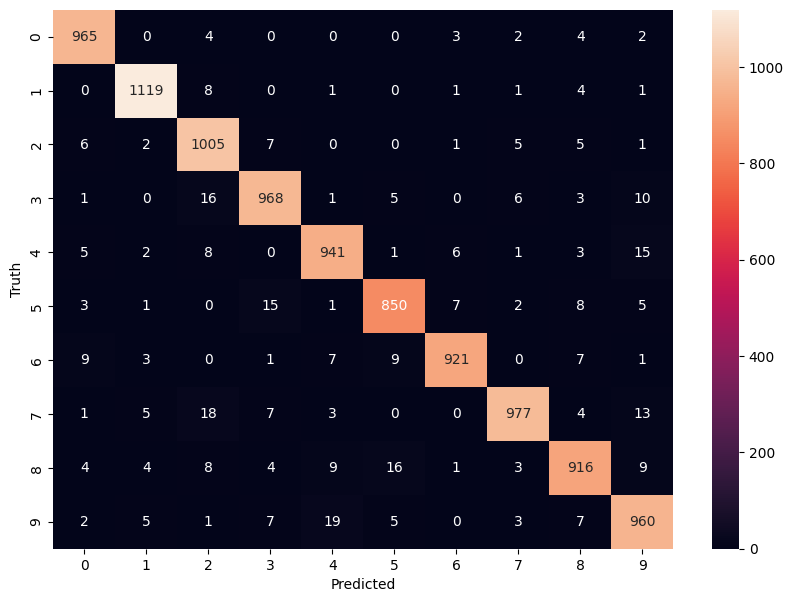

In [52]:
import seaborn as sn

plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

What our confusion matrix is telling us is:

- 965 times, the truth was 0 and our model correctly predicted it to be 0
- 1 time, the truth was 3 and our model predicted it to be 0
- 19 times, the truth was 9 but our model predicted it to be 4
...

# **Regression Task**

**Regression** is used to predict a continuous variable(prediction target) based on predictors.

For example, predict house price based on land area, number of bedrooms and number of garages.

Basically, you will be training your model to find out an linear function/relation that connects your predictors to the prediction target.

Mathematically, if y is the prediction target, n is the total number of predictors, x(i) is the i-th predictor for 1<=i<=n and w(i) is the i-th weight/coefficient for 1<=i<=n, then the model is trying to find out the optimal weights w(i) that correctly represent the relationship:

y =  Σ w(i)x(i) + b, where b is a constant

Below, we load our data for the housing prices.

In [45]:
import pandas as pd

df = pd.read_csv('./datasets/housing.csv')

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Now, we are going to preprocess our data a bit for the model

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# For simplicity, we are not doing any preprocessing
X, y = df.drop("MedHouseVal", axis=1), df["MedHouseVal"]

# Split the data
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(X, y,test_size=0.2)

# Scale the data
X_train_scaled = scaler.fit_transform(new_X_train)
X_test_scaled = scaler.fit_transform(new_X_test)

Again, we now build the regression model.

In [53]:
model = Sequential()
# Input layer
model.add(Input((8,)))
# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
# Output layer
model.add(Dense(1)) # We do not use softmax here as it will not make sense. Softmax is mostly used for classfication problems

We are going to now compile the model.

In [48]:
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])

Now, we fit the model.

In [49]:
model.fit(X_train_scaled, new_y_train, epochs=10)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.8485 - mae: 0.6107 - r2_score: 0.3679 
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3960 - mae: 0.4488 - r2_score: 0.7050
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3685 - mae: 0.4323 - r2_score: 0.7255
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3564 - mae: 0.4223 - r2_score: 0.7345
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3652 - mae: 0.4140 - r2_score: 0.7279
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3644 - mae: 0.4055 - r2_score: 0.7286
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3224 - mae: 0.3951 - r2_score: 0.7598
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3144 - mae: 0.3902 - r2_score: 0.7658
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3091 - mae: 0.3866 - r2_score: 0.7697
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3001 - mae: 0.3799 - r2_score: 0.776

Let us evaluate the model now.

In [50]:
model.evaluate(X_test_scaled, new_y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5703 - mae: 1.4931 - r2_score: -3.3255


[5.570250511169434, 1.493064522743225, -3.3255014419555664]